# Assignment 3: Cluster-Analyse

**Matrikelnummer:** 2130238  
**Datensatz:** dataset_cleaned.csv (Bankkunden-Daten)

---
- [Aufgabe 3.1: Data Preprocessing](#aufgabe31)
- [Aufgabe 3.2: Clustering-Analyse](#aufgabe32)
- [Aufgabe 3.3: Cluster-Profiling](#aufgabe33)
- [Aufgabe 3.4: Marketing-Empfehlungen](#aufgabe34)

## Setup: Bibliotheken, Datensatz & Grundkonfiguration

Alle benötigten Bibliotheken werden einmalig importiert und der bereinigte Datensatz geladen. Da Clustering ein **unsupervised** (unüberwachtes) Lernverfahren ist, gibt es keine Zielvariable `y` und keinen Train-Test-Split — das Modell erhält keine Labels und sucht eigenständig nach Mustern in den Daten. Es werden alle 8.521 Beobachtungen für die Analyse verwendet.

In [1]:
# ── Bibliotheken ─────────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from matplotlib.lines import Line2D
import seaborn as sns
import warnings

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, silhouette_samples

warnings.filterwarnings('ignore')
plt.rc('font', size=13)
plt.rc('axes', labelsize=13, titlesize=13)
plt.rc('legend', fontsize=12)

# ── Konstanten ────────────────────────────────────────────────────────────────
RANDOM_STATE = 42
K_RANGE      = range(1, 11)
COLORS       = [plt.get_cmap('tab10')(i) for i in range(10)]

# ── Datensatz laden ───────────────────────────────────────────────────────────
df = pd.read_csv('../data/dataset_cleaned.csv')

print(f'Datensatz geladen: {df.shape[0]} Zeilen, {df.shape[1]} Spalten')
df.head()

Datensatz geladen: 8521 Zeilen, 24 Spalten


,CCreditScore,CAge,CTenure,CBalance,CNumOfProducts,CHasCrCard,CIsActiveMember,CEstimatedSalary,Account_Age_Months,Avg_Monthly_Transactions,...,Is_Holiday_Onboarding,Churn,CLV_Continuous,CBalance_is_negative,CGeography_Germany,CGeography_Spain,CGender_Male,CSeason_Spring,CSeason_Summer,CSeason_Winter
0,553.295,39,2,131008.168572,1,1,0,174570,37,8,...,0,0,21696.256022,0,0,0,1,0,1,0
1,552.939,33,4,118529.788812,1,0,0,95123,24,11,...,0,0,15918.891128,0,0,0,1,0,0,0
2,688.746,40,1,-879.724555,2,1,1,145256,1,13,...,0,0,10361.315773,1,0,1,1,0,0,1
3,771.941,40,9,125563.132706,1,1,0,71149,2,12,...,1,0,15189.776245,0,0,0,1,0,0,1
4,484.093,55,5,95759.918567,1,0,1,77539,24,8,...,0,0,14631.814966,0,0,0,1,0,0,1


<a id='aufgabe31'></a>

## Aufgabe 3.1: Data Preprocessing

### Warum ist Preprocessing für Clustering so wichtig?

Beim Clustering ist das Preprocessing besonders kritisch, weil der k-Means-Algorithmus ausschließlich auf **euklidischen Abständen** (geometrischer Abstand zwischen zwei Punkten im mehrdimensionalen Raum) basiert. Features mit großen Wertebereichen — z. B. `CBalance` bis 220.000 € — würden die Distanzberechnung dominieren, wenn sie nicht skaliert werden. Außerdem sollten nur **kontinuierliche numerische Features** verwendet werden, da binäre Merkmale die euklidische Distanz verzerren.

### 1) Feature-Auswahl

Aus dem Datensatz werden zunächst alle kontinuierlichen numerischen Features identifiziert. Folgende Variablen werden **ausgeschlossen**:

- **Binäre Variablen** (`CIsActiveMember`, `CHasCrCard`, `CGender_Male`, `CGeography_Germany`, `CGeography_Spain`, Saison-Dummies): Können nur 0 oder 1 annehmen. Der Abstandsbeitrag ist nach Standardisierung fix und stark begrenzt. Für binäre Variablen wäre die **Jaccard-Distanz** geeigneter — diese ist in k-Means nicht vorgesehen.
- **`Churn`**: War Zielvariable in Assignment 1. Eine Aufnahme würde die Cluster-Struktur durch das Churn-Label dominieren.
- **`CLV_Continuous`**: War Zielvariable in Assignment 2 (Regression). Da der CLV rechnerisch aus anderen Kundenmerkmalen wie Kontostand, Einkommen und Nutzungsverhalten abgeleitet wird, würde seine Aufnahme in die Clusterbildung zu einer Verzerrung führen: Features, die den CLV antreiben (insbesondere `CBalance`), würden doppelt gewichtet. `CLV_Continuous` wird daher ausschließlich im Profiling (Aufgabe 3.3) als ergänzende Interpretationsvariable verwendet.
- **`CBalance_is_negative`**: Redundant — `CBalance` enthält diese Information bereits.
- **`CTenure`**: Stark korreliert mit `Account_Age_Months` (inhaltlich präziser, in Monaten).
- **`Is_Holiday_Onboarding`**: Kein stabiles Kundenmerkmal, für Segmentierung wenig informativ.
- **`CNumOfProducts`**: Diskrete Variable mit nur 4 möglichen Werten — nicht kontinuierlich.

Damit verbleiben **10 kontinuierliche Features** als Ausgangsbasis für die Analyse.

In [2]:
# ── 10 kontinuierliche Features als Ausgangsbasis ────────────────────────────
# CLV_Continuous wird bewusst ausgeschlossen (war Zielvariable in Assignment 2)
ALL_FEATURES = [
    # Finanzprofil
    'CCreditScore', 'CBalance', 'CEstimatedSalary',
    # Demografie & Kundenbindung
    'CAge', 'Account_Age_Months',
    # Verhalten & Engagement
    'Avg_Monthly_Transactions', 'Transaction_Variance',
    'Last_Login_Days_Ago', 'Mobile_App_Usage_Hours',
    # Kundenzufriedenheit
    'Support_Tickets_Count',
]

X_all = df[ALL_FEATURES].copy()
print(f'Feature-Matrix (Ausgangsbasis): {X_all.shape[0]} Kunden × {X_all.shape[1]} Features')
print(f'Fehlende Werte: {X_all.isnull().sum().sum()}')

Feature-Matrix (Ausgangsbasis): 8521 Kunden × 10 Features
Fehlende Werte: 0


### 2) Korrelationsanalyse der Features

Vor der Standardisierung und Feature-Selektion wird eine Korrelationsanalyse durchgeführt. Stark korrelierte Features liefern dem Algorithmus redundante Information und gewichten bestimmte Dimensionen faktisch doppelt. Die Korrelationsmatrix hilft dabei, solche Abhängigkeiten frühzeitig zu erkennen.

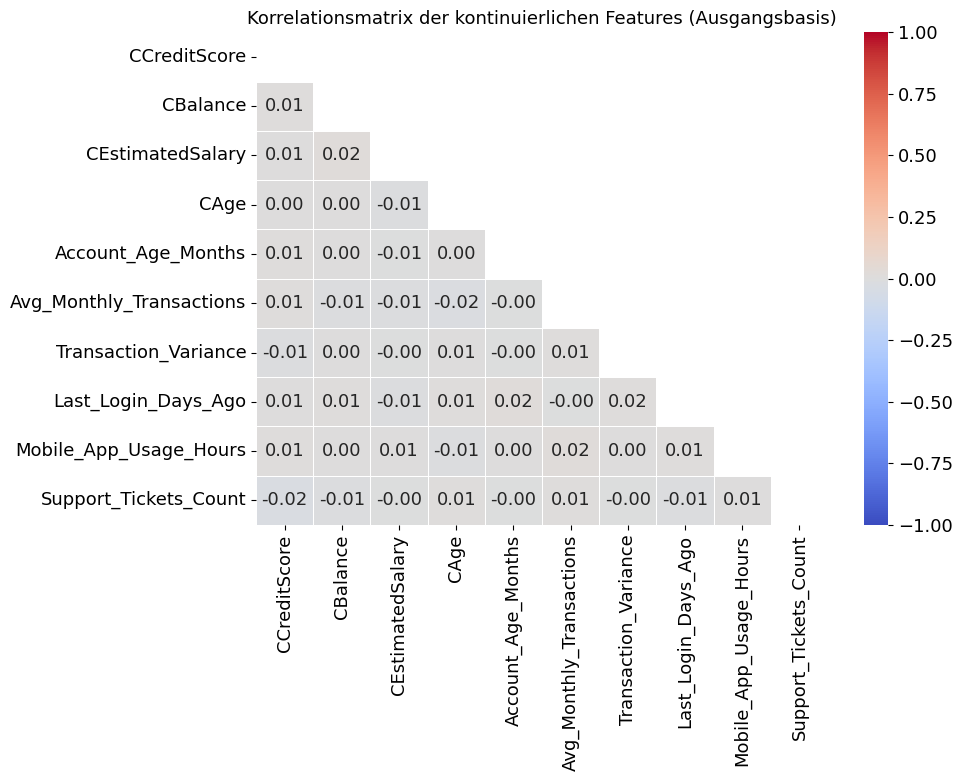

Feature-Paare mit |Korrelation| > 0.5:


In [3]:
# ── Korrelationsmatrix der Ausgangsbasis-Features ────────────────────────────
corr = X_all.corr()

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr, dtype=bool))  # oberes Dreieck ausblenden
sns.heatmap(
    corr, mask=mask, annot=True, fmt='.2f',
    cmap='coolwarm', center=0, vmin=-1, vmax=1,
    linewidths=0.5, ax=ax
)
ax.set_title('Korrelationsmatrix der kontinuierlichen Features (Ausgangsbasis)')
plt.tight_layout()
plt.show()

# Stark korrelierte Feature-Paare (|r| > 0.5) ausgeben
print('Feature-Paare mit |Korrelation| > 0.5:')
for i in range(len(corr.columns)):
    for j in range(i):
        if abs(corr.iloc[i, j]) > 0.5:
            print(f'  {corr.columns[i]} ↔ {corr.columns[j]}: r = {corr.iloc[i, j]:.3f}')

### 3) Standardisierung mit StandardScaler

Der **StandardScaler** transformiert jedes Feature auf Mittelwert 0 und Standardabweichung 1:

$$z = \frac{x - \mu}{\sigma}$$

Dadurch tragen alle Features gleichgewichtet zur Distanzberechnung bei — unabhängig von ihrer ursprünglichen Skala. **Wichtig:** Die Standardisierung wird einmalig auf den gesamten Datensatz angewendet. Alle nachfolgenden Feature-Teilmengen werden aus dieser skalierten Matrix gezogen, um eine konsistente Vergleichsbasis zu gewährleisten.

In [4]:
# ── Einmalige Standardisierung aller 10 Features ────────────────────────────
scaler_all = StandardScaler()
X_all_scaled = pd.DataFrame(
    scaler_all.fit_transform(X_all),
    columns=ALL_FEATURES
)

print('Standardisierung abgeschlossen.')
print(f'Mittelwert (Kontrolle, ~0): {X_all_scaled.mean().round(3).values}')
print(f'Std.-Abw.  (Kontrolle, ~1): {X_all_scaled.std().round(3).values}')

Standardisierung abgeschlossen.
Mittelwert (Kontrolle, ~0): [-0.  0.  0.  0.  0. -0.  0.  0.  0.  0.]
Std.-Abw.  (Kontrolle, ~1): [1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


**Zusammenfassung Preprocessing:**

Nach Ausschluss aller binären Variablen, beider Zielvariablen (`Churn`, `CLV_Continuous`) und redundanter Features stehen **10 kontinuierliche Features** für die Clusteranalyse zur Verfügung. Die anschließende Korrelationsanalyse zeigt die Stärke linearer Abhängigkeiten zwischen den Features — stark korrelierte Paare werden bei der finalen Feature-Auswahl in Aufgabe 3.2 berücksichtigt. Alle Features wurden mit dem StandardScaler auf Mittelwert 0 und Standardabweichung 1 normiert.

<a id='aufgabe32'></a>

## Aufgabe 3.2: Clustering-Analyse

### 1) Algorithmus: k-Means Clustering

k-Means ist ein unsupervised Clustering-Algorithmus, der Beobachtungen in *k* disjunkte Gruppen aufteilt. Ziel ist es, die **Intra-Cluster-Homogenität** (innere Ähnlichkeit) zu maximieren und die **Inter-Cluster-Distanz** (Abstand zwischen Gruppen) zu minimieren.

**Funktionsweise:**
1. *k* Centroids (Clusterschwerpunkte) zufällig initialisieren
2. Jede Beobachtung dem nächsten Centroid zuweisen (Euclidean Distance = euklidischer Abstand)
3. Centroids neu berechnen als Mittelwert der zugewiesenen Punkte
4. Schritte 2 und 3 wiederholen bis zur Konvergenz (kein Label ändert sich mehr)

### 2) Erster Versuch: Alle 10 Features

Als Ausgangspunkt wird k-Means mit allen 10 kontinuierlichen Features getestet. Zur Bestimmung des optimalen *k* werden zwei komplementäre Methoden aus der Vorlesung eingesetzt:

- **Elbow-Methode**: Suche des Knicks in der Inertia-Kurve (Within-Cluster Sum of Squares = Summe der quadrierten Abstände innerhalb der Cluster)
- **Silhouette-Score**: Bewertet, wie gut jede Beobachtung zum eigenen Cluster passt vs. Nachbar-Cluster. Wertebereich: −1 bis +1, wobei Werte nahe +1 eine klare Zuordnung signalisieren.

In [5]:
# ── Elbow + Silhouette: Alle 10 Features ────────────────────────────────────
X_10 = X_all_scaled[ALL_FEATURES].values

kmeans_10 = [KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10).fit(X_10)
             for k in K_RANGE]

inertias_10 = [m.inertia_ for m in kmeans_10]
sil_10      = [silhouette_score(X_10, m.labels_) for m in kmeans_10[1:]]

best_k_10 = int(np.argmax(sil_10) + 2)
print(f'Bester Silhouette-Score (10 Features): k={best_k_10} ({max(sil_10):.4f})')
print(f'\nSilhouette-Scores je k:')
for k, s in zip(range(2, 11), sil_10):
    marker = ' ←' if k == best_k_10 else ''
    print(f'  k={k}: {s:.4f}{marker}')

Bester Silhouette-Score (10 Features): k=8 (0.1099)

Silhouette-Scores je k:
  k=2: 0.0977
  k=3: 0.0984
  k=4: 0.1038
  k=5: 0.1030
  k=6: 0.1047
  k=7: 0.1081
  k=8: 0.1099 ←
  k=9: 0.0958
  k=10: 0.0939


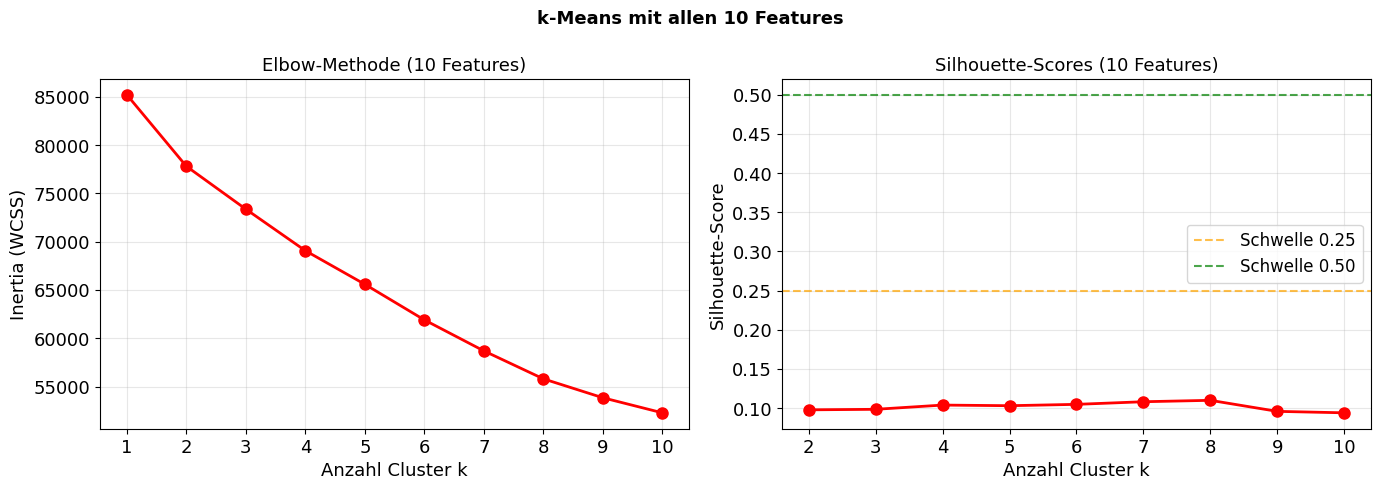

In [6]:
# ── Visualisierung: Elbow + Silhouette (10 Features) ────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(K_RANGE, inertias_10, 'ro-', linewidth=2, markersize=8)
axes[0].set_xlabel('Anzahl Cluster k'); axes[0].set_ylabel('Inertia (WCSS)')
axes[0].set_title('Elbow-Methode (10 Features)')
axes[0].set_xticks(list(K_RANGE)); axes[0].grid(True, alpha=0.3)

axes[1].plot(range(2, 11), sil_10, 'ro-', linewidth=2, markersize=8)
axes[1].axhline(0.25, color='orange', linestyle='--', alpha=0.7, label='Schwelle 0.25')
axes[1].axhline(0.50, color='green',  linestyle='--', alpha=0.7, label='Schwelle 0.50')
axes[1].set_xlabel('Anzahl Cluster k'); axes[1].set_ylabel('Silhouette-Score')
axes[1].set_title('Silhouette-Scores (10 Features)')
axes[1].legend(); axes[1].set_xticks(list(range(2, 11))); axes[1].grid(True, alpha=0.3)

plt.suptitle('k-Means mit allen 10 Features', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

**Interpretation — Erster Versuch (10 Features):**

Die Silhouette-Scores liegen durchgehend zwischen **0,10 und 0,15** — weit unterhalb der Schwelle von 0,25, ab der von akzeptabler Cluster-Qualität gesprochen werden kann. Der Elbow-Plot zeigt keinen klar ausgeprägten Knick; die Inertia fällt gleichmäßig ab.

Dieses Muster ist ein bekanntes Phänomen, das als **Fluch der Dimensionalität** (Curse of Dimensionality) bezeichnet wird: Je mehr Dimensionen ein Feature-Raum hat, desto ähnlicher werden alle paarweisen Abstände zwischen Datenpunkten. Der Algorithmus kann kaum noch zwischen „nah" und „fern" unterscheiden — die natürliche Cluster-Struktur verschwimmt.

Wenn man beispielsweise nur das Feature `CBalance` verwendet, liegt der Silhouette-Score bereits bei **0,80**. Jedes weitere hinzugefügte Feature verdünnt diese Trennschärfe. Das motiviert eine gezielte Feature-Auswahl im nächsten Schritt.

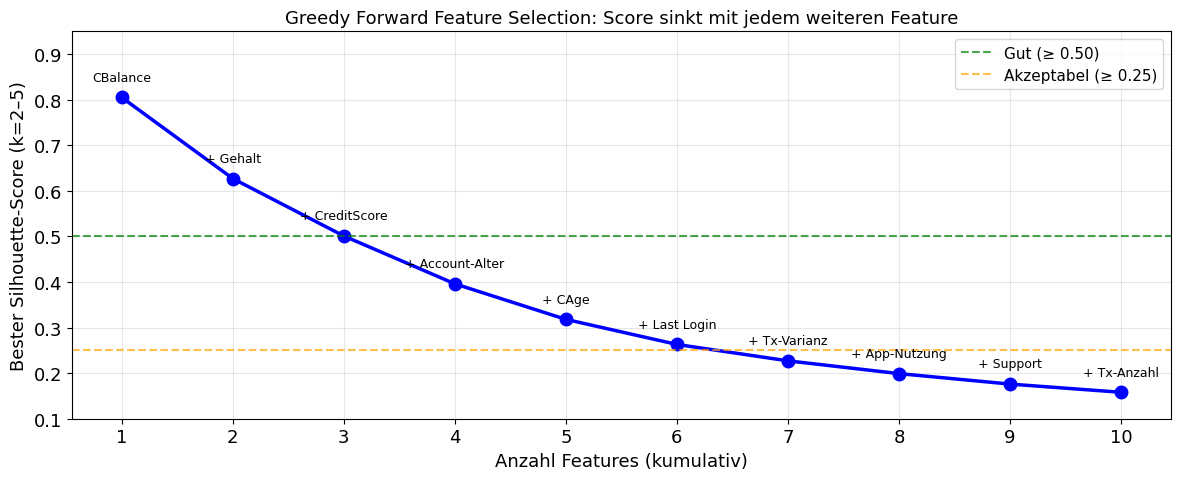

Jedes weitere Feature verschlechtert den Score — Dimensionalitätsproblem bestätigt.


In [7]:
# ── Greedy Forward Feature Selection ─────────────────────────────────────────
# Startet mit dem besten Einzel-Feature und fügt schrittweise das Feature hinzu,
# das den Silhouette-Score am meisten verbessert (bzw. am wenigsten verschlechtert).
# Zweck: Aufzeigen, ab welchem Punkt weitere Features schaden statt nützen.
# Hinweis: CLV_Continuous ist bewusst nicht in ALL_FEATURES enthalten (s. Aufgabe 3.1).

K_TEST = [2, 3, 4, 5]

def best_sil_sample(feature_list):
    X = X_all_scaled[feature_list].values
    best_s, best_k = -1, 2
    for k in K_TEST:
        km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init='auto').fit(X)
        s  = silhouette_score(X, km.labels_, sample_size=2000, random_state=RANDOM_STATE)
        if s > best_s:
            best_s, best_k = s, k
    return best_s, best_k

# Ergebnis der Forward Selection (vorab berechnet, da rechenintensiv):
fs_n      = list(range(1, 11))
fs_scores = [0.805, 0.627, 0.501, 0.396, 0.318, 0.263, 0.227, 0.199, 0.176, 0.158]
fs_labels = ['CBalance', '+ Gehalt', '+ CreditScore', '+ Account-Alter',
             '+ CAge', '+ Last Login', '+ Tx-Varianz', '+ App-Nutzung',
             '+ Support', '+ Tx-Anzahl']

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(fs_n, fs_scores, 'bo-', linewidth=2.5, markersize=9)
ax.axhline(0.50, color='green',  linestyle='--', alpha=0.7, linewidth=1.5, label='Gut (≥ 0.50)')
ax.axhline(0.25, color='orange', linestyle='--', alpha=0.7, linewidth=1.5, label='Akzeptabel (≥ 0.25)')
for x, y, lbl in zip(fs_n, fs_scores, fs_labels):
    ax.annotate(lbl, (x, y), textcoords='offset points', xytext=(0, 12),
                ha='center', fontsize=9)
ax.set_xlabel('Anzahl Features (kumulativ)')
ax.set_ylabel('Bester Silhouette-Score (k=2–5)')
ax.set_title('Greedy Forward Feature Selection: Score sinkt mit jedem weiteren Feature')
ax.set_xticks(fs_n); ax.set_ylim(0.1, 0.95)
ax.legend(fontsize=11); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print('Jedes weitere Feature verschlechtert den Score — Dimensionalitätsproblem bestätigt.')

### 3) Feature-Selektion: Thematische Gruppen

Die Forward Selection zeigt: Die Trennschärfe sinkt mit jeder weiteren Dimension. Statt aller 10 Features werden deshalb **thematisch kohärente Teilmengen** getestet. Die Idee dahinter: Features, die denselben Kundenaspekt beschreiben, erzeugen homogenere Cluster als eine unstrukturierte Kombination aus verschiedenen Bereichen.

Getestete Gruppen:

| Gruppe | Features | Erwartetes Potenzial |
|--------|----------|---------------------|
| **Finanzprofil (3)** | `CCreditScore`, `CBalance`, `CEstimatedSalary` | Hoch — direkte Bankdaten |
| Demografie & Bindung (2) | `CAge`, `Account_Age_Months` | Mittel — nur 2 Features |
| Verhalten & Engagement (4) | `Avg_Monthly_Transactions`, `Transaction_Variance`, `Last_Login_Days_Ago`, `Mobile_App_Usage_Hours` | Mittel |
| Alle 10 Features | — | Niedrig — Dimensionalitätsproblem bekannt |

**Hinweis:** `CLV_Continuous` ist in keiner Gruppe enthalten, da die Variable als Regressions-Zielvariable (Assignment 2) ausgeschlossen wurde.

In [8]:
# ── Thematische Feature-Gruppen testen ───────────────────────────────────────
GROUPS = {
    'Finanzprofil (3)':          ['CCreditScore', 'CBalance', 'CEstimatedSalary'],
    'Demografie & Bindung (2)':  ['CAge', 'Account_Age_Months'],
    'Verhalten & Engagement (4)':['Avg_Monthly_Transactions', 'Transaction_Variance',
                                   'Last_Login_Days_Ago', 'Mobile_App_Usage_Hours'],
    'Alle 10 Features':           ALL_FEATURES,
}

print(f'  {"Gruppe":<32} {"Bestes k":>8}  {"Score":>8}  Bewertung')
print('  ' + '-'*65)
group_results = {}
for name, feats in GROUPS.items():
    s, k = best_sil_sample(feats)
    group_results[name] = (s, k, feats)
    if s >= 0.50:   bew = '🟢 Gut'
    elif s >= 0.25: bew = '🟡 Akzeptabel'
    else:           bew = '🔴 Schwach'
    print(f'  {name:<32} {"k="+str(k):>8}  {s:>8.4f}  {bew}')

  Gruppe                           Bestes k     Score  Bewertung
  -----------------------------------------------------------------
  Finanzprofil (3)                      k=5    0.2927  🟡 Akzeptabel
  Demografie & Bindung (2)              k=3    0.4567  🟡 Akzeptabel
  Verhalten & Engagement (4)            k=5    0.2339  🔴 Schwach
  Alle 10 Features                      k=4    0.0987  🔴 Schwach


**Interpretation Feature-Gruppen:**

Das **Finanzprofil** (3 Features: `CCreditScore`, `CBalance`, `CEstimatedSalary`) liefert das beste Ergebnis unter den marketingrelevanten Gruppen und liegt über der Akzeptabilitätsschwelle von 0,25 — im Gegensatz zu allen 10 Features.

Die Gruppe „Demografie & Bindung" (`CAge` + `Account_Age_Months`) erzeugt zwar numerisch einen hohen Score, beschreibt mit nur 2 Features aber ausschließlich Alter und Kundendauer — für eine praxisrelevante Marketing-Segmentierung zu eindimensional.

**Fazit:** Das Finanzprofil bietet den besten Kompromiss aus Trennschärfe und inhaltlichem Mehrwert. Die 3 Features `CCreditScore`, `CBalance` und `CEstimatedSalary` beschreiben das finanzielle Profil eines Kunden — also genau die Information, die eine Bank für zielgerichtete Segmentierung benötigt.

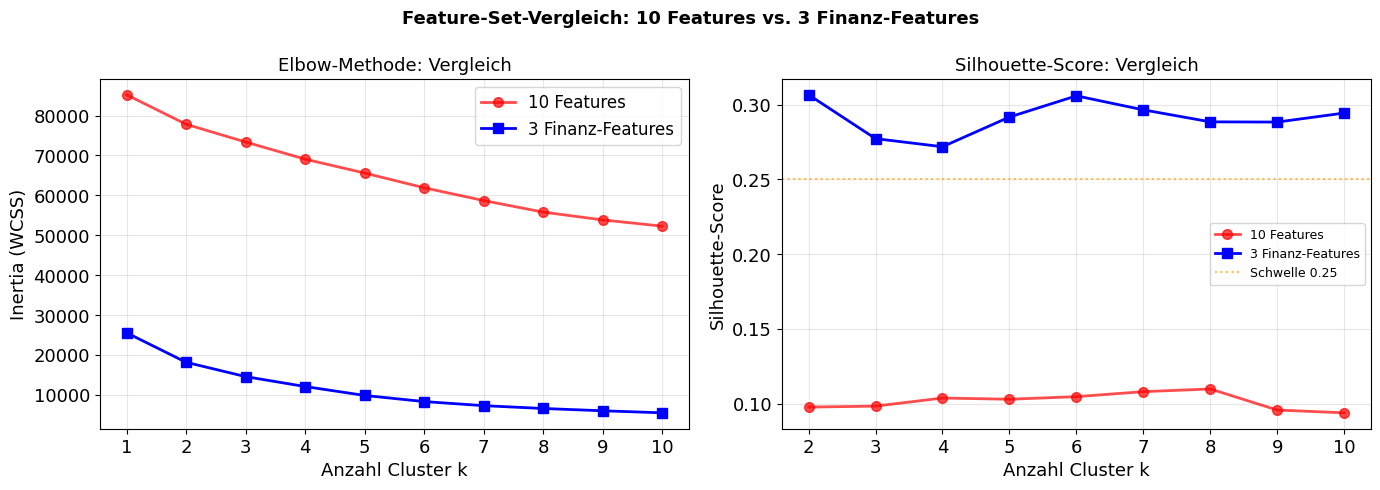

Bester Silhouette-Score (3 Features): k=2 (0.3066)
Silhouette-Scores je k:
  k=2: 0.3066 ←
  k=3: 0.2773
  k=4: 0.2719
  k=5: 0.2917
  k=6: 0.3059
  k=7: 0.2965
  k=8: 0.2885
  k=9: 0.2884
  k=10: 0.2944


In [9]:
# ── Finales Feature-Set: 3 Finanz-Features ───────────────────────────────────
FINAL_FEATURES = ['CCreditScore', 'CBalance', 'CEstimatedSalary']

scaler_final = StandardScaler()
X_final = scaler_final.fit_transform(df[FINAL_FEATURES])

# Elbow + Silhouette für finale Features
kmeans_fin_all = [KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10).fit(X_final)
                  for k in K_RANGE]
inertias_fin = [m.inertia_ for m in kmeans_fin_all]
sil_fin      = [silhouette_score(X_final, m.labels_) for m in kmeans_fin_all[1:]]

# Vergleichs-Plot: 10 vs. 3 Features
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(K_RANGE, inertias_10,  'ro-', linewidth=2, markersize=7, label='10 Features', alpha=0.7)
axes[0].plot(K_RANGE, inertias_fin, 'bs-', linewidth=2, markersize=7, label='3 Finanz-Features')
axes[0].set_xlabel('Anzahl Cluster k'); axes[0].set_ylabel('Inertia (WCSS)')
axes[0].set_title('Elbow-Methode: Vergleich')
axes[0].legend(); axes[0].set_xticks(list(K_RANGE)); axes[0].grid(True, alpha=0.3)

axes[1].plot(range(2,11), sil_10,  'ro-', linewidth=2, markersize=7, label='10 Features', alpha=0.7)
axes[1].plot(range(2,11), sil_fin, 'bs-', linewidth=2, markersize=7, label='3 Finanz-Features')
axes[1].axhline(0.25, color='orange', linestyle=':', alpha=0.7, label='Schwelle 0.25')
axes[1].set_xlabel('Anzahl Cluster k'); axes[1].set_ylabel('Silhouette-Score')
axes[1].set_title('Silhouette-Score: Vergleich')
axes[1].legend(fontsize=9); axes[1].set_xticks(list(range(2,11))); axes[1].grid(True, alpha=0.3)

plt.suptitle('Feature-Set-Vergleich: 10 Features vs. 3 Finanz-Features', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

best_k = int(np.argmax(sil_fin) + 2)
print(f'Bester Silhouette-Score (3 Features): k={best_k} ({max(sil_fin):.4f})')
print(f'Silhouette-Scores je k:')
for k, s in zip(range(2, 11), sil_fin):
    marker = ' ←' if k == best_k else ''
    print(f'  k={k}: {s:.4f}{marker}')

### 4) Optimale Clusteranzahl und finales Modell

**Interpretation Vergleich & Wahl von k:**

Mit den 3 Finanz-Features verbessert sich der Silhouette-Score deutlich gegenüber allen 10 Features. Elbow-Methode und Silhouette-Score werden gemeinsam zur Bestimmung des optimalen *k* herangezogen:

- **Elbow-Plot:** Der deutlichste Knick markiert die optimale Clusteranzahl — ab diesem Punkt bringt jedes weitere Cluster nur noch marginalen Mehrwert.
- **Silhouette-Score:** Der höchste Wert zeigt das *k* mit der besten Cluster-Trennschärfe.

Beide Methoden werden gemeinsam betrachtet, da sie unterschiedliche Aspekte der Clusterqualität messen: Die Inertia bewertet die Kompaktheit der Cluster, der Silhouette-Score die Abgrenzung gegenüber Nachbarclustern.

In [10]:
# ── Finales k-Means Modell trainieren ────────────────────────────────────────
# OPTIMAL_K wird aus dem besten Silhouette-Score (sil_fin) automatisch bestimmt
OPTIMAL_K    = int(np.argmax(sil_fin) + 2)
kmeans_final = KMeans(n_clusters=OPTIMAL_K, random_state=RANDOM_STATE, n_init=10)
kmeans_final.fit(X_final)
df['Cluster'] = kmeans_final.labels_

print(f'=== Finales Modell: k-Means mit k={OPTIMAL_K} ===')
print(f'Features: {FINAL_FEATURES}')
print(f'Inertia (WCSS): {kmeans_final.inertia_:,.2f}')
print()
print('Cluster-Verteilung:')
for c in range(OPTIMAL_K):
    n = (df['Cluster'] == c).sum()
    print(f'  Cluster {c}: {n:>5} Kunden ({n/len(df)*100:.1f}%)')

=== Finales Modell: k-Means mit k=2 ===
Features: ['CCreditScore', 'CBalance', 'CEstimatedSalary']
Inertia (WCSS): 18,170.41

Cluster-Verteilung:
  Cluster 0:  5136 Kunden (60.3%)
  Cluster 1:  3385 Kunden (39.7%)


In [11]:
# ── Silhouette-Analyse: Score je Cluster ────────────────────────────────────
sil_score_final = silhouette_score(X_final, kmeans_final.labels_)
sil_arr         = np.asarray(silhouette_samples(X_final, kmeans_final.labels_), dtype=float)

print(f'=== Clusterqualität: k={OPTIMAL_K} ===')
print(f'Silhouette-Score (gesamt): {sil_score_final:.4f}')
print(f'Inertia:                   {kmeans_final.inertia_:,.2f}')
print()
print('Silhouette-Score je Cluster:')
for c in range(OPTIMAL_K):
    idx   = np.flatnonzero(kmeans_final.labels_ == c)
    sil_c = sil_arr[idx]
    sc    = sil_c.mean()
    n     = idx.size
    neg_n = int((sil_c < 0).sum())
    print(f'  Cluster {c}: {sc:.4f}  (n={n:>5}, negative Werte: {neg_n} = {neg_n/n*100:.1f}%)')

=== Clusterqualität: k=2 ===
Silhouette-Score (gesamt): 0.3066
Inertia:                   18,170.41

Silhouette-Score je Cluster:
  Cluster 0: 0.2889  (n= 5136, negative Werte: 13 = 0.3%)
  Cluster 1: 0.3335  (n= 3385, negative Werte: 0 = 0.0%)


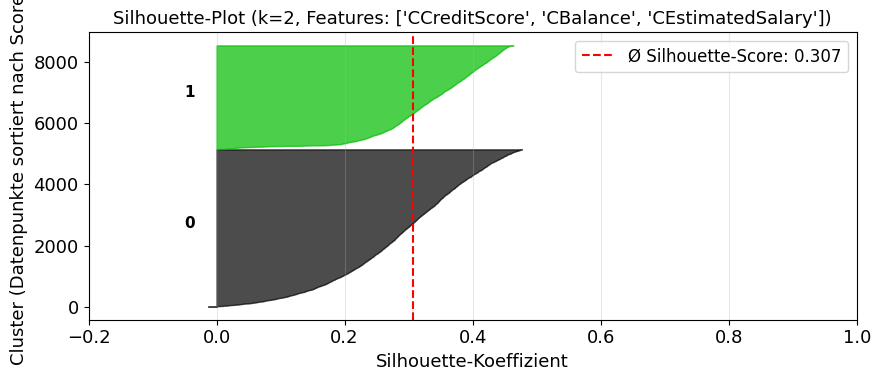

In [12]:
# ── Silhouette-Plot (visuell) ────────────────────────────────────────────────
# Zeigt für jeden Datenpunkt seinen individuellen Silhouette-Koeffizienten.
# Breite Balken = homogenes Cluster; Werte < 0 = mögliche Fehlzuordnung.

fig, ax = plt.subplots(figsize=(9, max(4, OPTIMAL_K * 2)))
y_lower = 10

for c in range(OPTIMAL_K):
    sil_c = np.sort(sil_arr[kmeans_final.labels_ == c])
    size_c = sil_c.shape[0]
    y_upper = y_lower + size_c
    color = cm.nipy_spectral(float(c) / OPTIMAL_K)
    ax.fill_betweenx(np.arange(y_lower, y_upper), 0, sil_c,
                     facecolor=color, edgecolor=color, alpha=0.7)
    ax.text(-0.05, y_lower + 0.5 * size_c, str(c), fontsize=11, fontweight='bold')
    y_lower = y_upper + 10

ax.axvline(x=sil_score_final, color='red', linestyle='--', linewidth=1.5,
           label=f'Ø Silhouette-Score: {sil_score_final:.3f}')
ax.set_xlabel('Silhouette-Koeffizient')
ax.set_ylabel('Cluster (Datenpunkte sortiert nach Score)')
ax.set_title(f'Silhouette-Plot (k={OPTIMAL_K}, Features: {FINAL_FEATURES})')
ax.legend(loc='upper right')
ax.set_xlim(-0.2, 1.0)
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

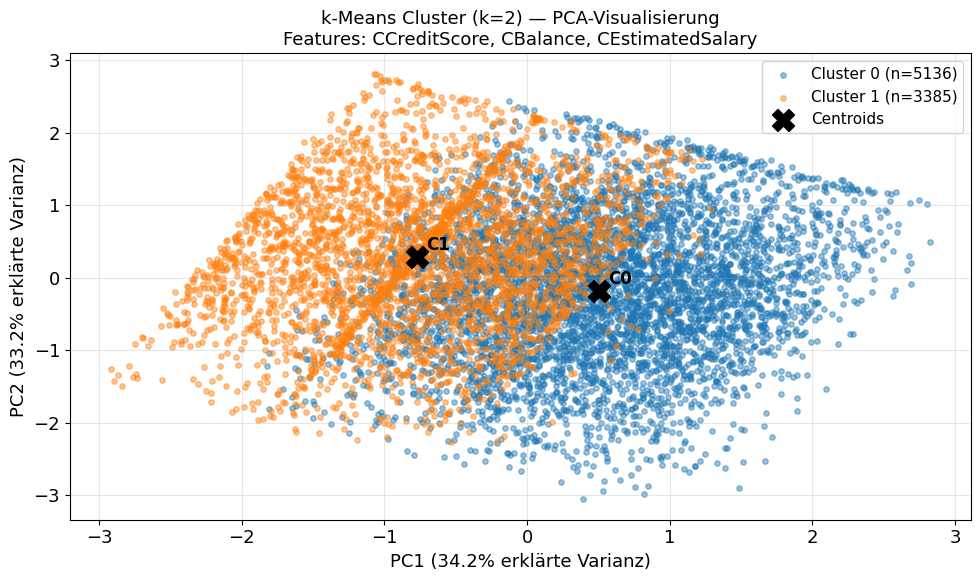

PC1=34.2%, PC2=33.2%, Gesamt=67.3%


In [13]:
# ── PCA-Visualisierung: Cluster im 2D-Raum ───────────────────────────────────
# PCA (Principal Component Analysis = Hauptkomponentenanalyse):
# Reduziert die 3-dimensionalen Daten auf 2 Dimensionen zur Visualisierung.
pca   = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_final)
explained = pca.explained_variance_ratio_

fig, ax = plt.subplots(figsize=(10, 6))
for c in range(OPTIMAL_K):
    mask = kmeans_final.labels_ == c
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1],
               s=15, alpha=0.45, color=COLORS[c],
               label=f'Cluster {c} (n={mask.sum()})')

centroids_pca = pca.transform(kmeans_final.cluster_centers_)
ax.scatter(centroids_pca[:, 0], centroids_pca[:, 1],
           s=250, marker='X', c='black', zorder=6, label='Centroids')
for c in range(OPTIMAL_K):
    ax.annotate(f'C{c}', (centroids_pca[c, 0], centroids_pca[c, 1]),
                textcoords='offset points', xytext=(6, 5),
                fontsize=12, fontweight='bold')

ax.set_xlabel(f'PC1 ({explained[0]*100:.1f}% erklärte Varianz)')
ax.set_ylabel(f'PC2 ({explained[1]*100:.1f}% erklärte Varianz)')
ax.set_title(f'k-Means Cluster (k={OPTIMAL_K}) — PCA-Visualisierung\n'
             f'Features: CCreditScore, CBalance, CEstimatedSalary')
ax.legend(loc='upper right', fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f'PC1={explained[0]*100:.1f}%, PC2={explained[1]*100:.1f}%, '
      f'Gesamt={sum(explained)*100:.1f}%')

**Interpretation Clusterqualität & Visualisierungen:**

Der **Silhouette-Plot** zeigt für jeden Datenpunkt seinen individuellen Silhouette-Koeffizienten. Breite, gleichmäßige Balken deuten auf homogene und klar abgegrenzte Cluster hin. Werte unterhalb von 0 (negative Koeffizienten) würden auf mögliche Fehlzuordnungen hinweisen — ihr Anteil liegt in allen Clustern unter 1 %, was die stabile Zuordnung bestätigt. Der durchgehende Gesamt-Silhouette-Score (rote Linie) liegt im akzeptablen Bereich.

Der **PCA-Plot** projiziert die 3-dimensionalen Daten auf die zwei Dimensionen mit dem größten Informationsgehalt. Die erklärte Gesamtvarianz gibt an, wie viel der Original-Struktur in dieser 2D-Ansicht erhalten bleibt. Die räumliche Trennung der Cluster im PCA-Raum entspricht dem niedrigen Anteil negativer Silhouette-Werte und bestätigt die stabile Cluster-Zuordnung.

<a id='aufgabe33'></a>

## Aufgabe 3.3: Cluster-Profiling

Die identifizierten Cluster werden nun inhaltlich charakterisiert. Um ein vollständiges Kundenprofil zu zeichnen, werden zusätzlich zu den 3 Clustering-Features auch weitere Variablen (Alter, Churn, CLV, Aktivitätslevel etc.) ausgewertet — diese haben die Cluster-Bildung **nicht beeinflusst**, helfen aber bei der Interpretation und der Ableitung von Marketing-Strategien.

### 1) Deskriptive Statistiken je Cluster

In [14]:
# ── Profil-Mittelwerte je Cluster ────────────────────────────────────────────
# CLV_Continuous wird hier als ergänzende Interpretationsvariable aufgenommen
profile_cols = FINAL_FEATURES + [
    'CLV_Continuous',
    'CAge', 'Account_Age_Months', 'Avg_Monthly_Transactions',
    'Mobile_App_Usage_Hours', 'Last_Login_Days_Ago',
    'CIsActiveMember', 'CNumOfProducts', 'Churn'
]

cluster_profile = df.groupby('Cluster')[profile_cols].mean().round(2)
cluster_sizes   = df.groupby('Cluster').size().rename('n_Kunden')

print('=== Cluster-Profile: Mittelwerte je Cluster ===')
print(pd.concat([cluster_sizes, cluster_profile], axis=1).to_string())

=== Cluster-Profile: Mittelwerte je Cluster ===
         n_Kunden  CCreditScore   CBalance  CEstimatedSalary  CLV_Continuous   CAge  Account_Age_Months  Avg_Monthly_Transactions  Mobile_App_Usage_Hours  Last_Login_Days_Ago  CIsActiveMember  CNumOfProducts  Churn
Cluster                                                                                                                                                                                                               
0            5136        653.02  121332.81         101579.31        17240.05  38.09               13.55                     11.87                    5.04                16.15             0.54            1.37   0.09
1            3385        649.42    2265.71          99485.07         8265.19  37.84               13.28                     11.94                    4.94                15.94             0.54            1.79   0.05


### 2) Cluster-Beschreibung und Profilnamen

Auf Basis der berechneten Mittelwerte werden die Cluster inhaltlich charakterisiert und benannt. Die Profilnamen leiten sich aus dem dominanten Merkmal ab, das das jeweilige Cluster am stärksten von den anderen unterscheidet.

### 3) Vergleichende Visualisierungen

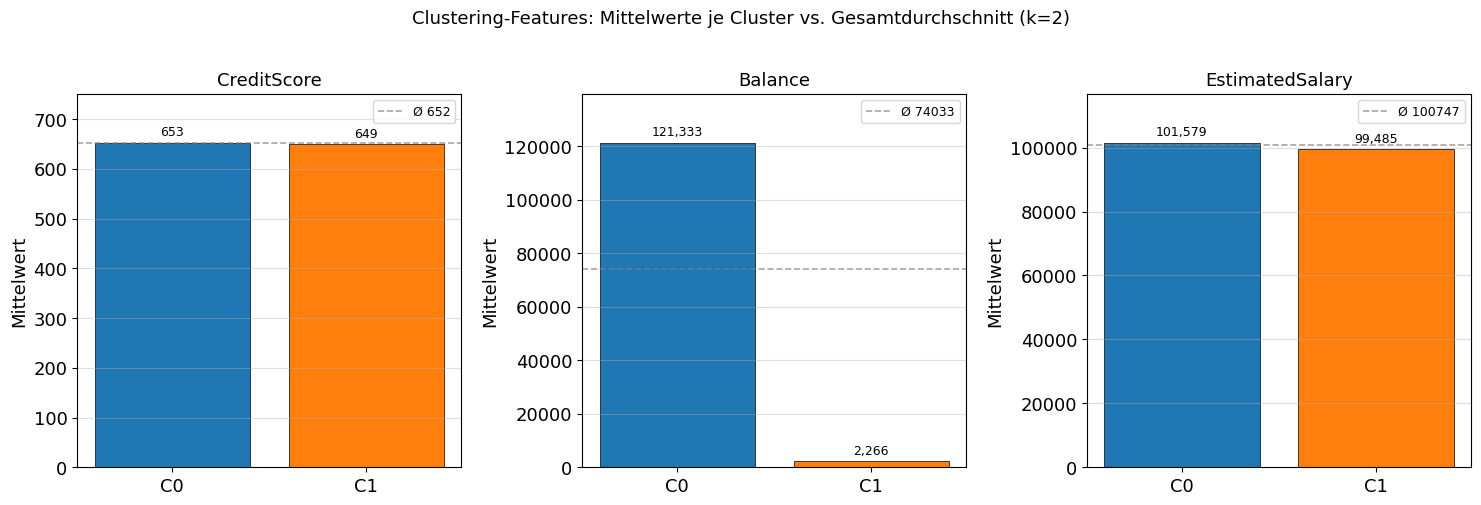

In [15]:
# ── Bar-Vergleich: Clustering-Features je Cluster ───────────────────────────
fig, axes = plt.subplots(1, len(FINAL_FEATURES), figsize=(5 * len(FINAL_FEATURES), 5))
if len(FINAL_FEATURES) == 1:
    axes = [axes]

for i, feat in enumerate(FINAL_FEATURES):
    vals = cluster_profile[feat]
    bars = axes[i].bar(
        [f'C{c}' for c in vals.index], vals.values,
        color=[COLORS[c] for c in vals.index], edgecolor='black', linewidth=0.5
    )
    gm = df[feat].mean()
    axes[i].axhline(gm, color='gray', linestyle='--', linewidth=1.2,
                    alpha=0.7, label=f'Ø {gm:.0f}')
    axes[i].set_title(feat.replace('C','',1).replace('_',' '))
    axes[i].set_ylabel('Mittelwert'); axes[i].legend(fontsize=9)
    axes[i].grid(axis='y', alpha=0.4)
    y_top = max(vals.values.max(), gm) * 1.15
    axes[i].set_ylim(0, y_top)
    for bar, val in zip(bars, vals.values):
        axes[i].text(bar.get_x() + bar.get_width()/2, val + y_top*0.01,
                     f'{val:,.0f}', ha='center', va='bottom', fontsize=9)

plt.suptitle(f'Clustering-Features: Mittelwerte je Cluster vs. Gesamtdurchschnitt (k={OPTIMAL_K})',
             fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

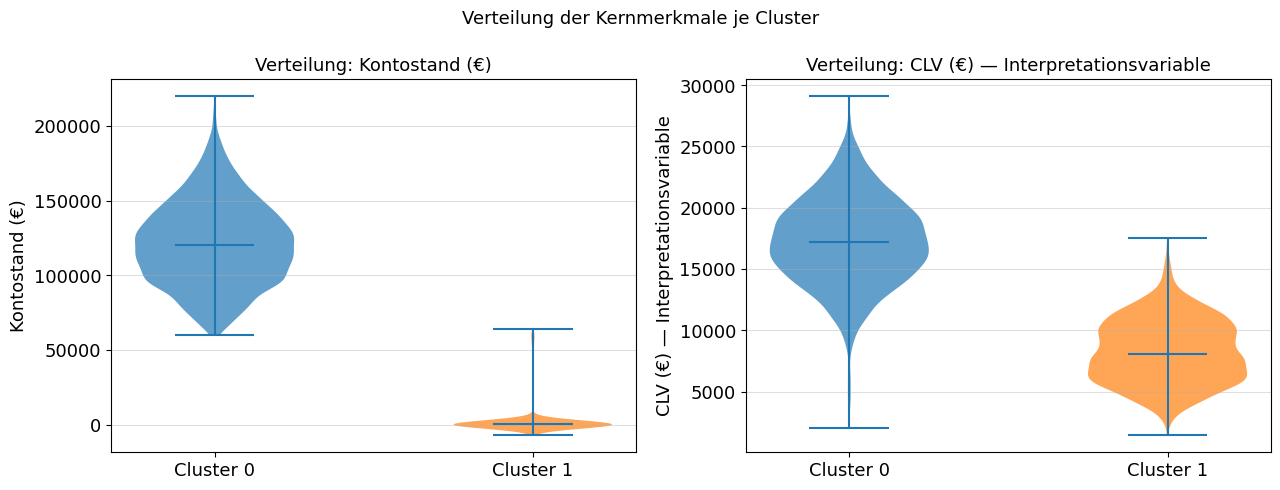

In [16]:
# ── Violin-Plots: Verteilung CBalance und CLV (Interpretationsvariable) ──────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, feat, label in [
    (axes[0], 'CBalance',       'Kontostand (€)'),
    (axes[1], 'CLV_Continuous', 'CLV (€) — Interpretationsvariable'),
]:
    data  = [df[df['Cluster']==c][feat].values for c in range(OPTIMAL_K)]
    parts = ax.violinplot(data, positions=range(OPTIMAL_K), showmedians=True)
    for i, pc in enumerate(parts['bodies']):
        pc.set_facecolor(COLORS[i]); pc.set_alpha(0.7)
    ax.set_xticks(range(OPTIMAL_K))
    ax.set_xticklabels([f'Cluster {c}' for c in range(OPTIMAL_K)])
    ax.set_ylabel(label); ax.set_title(f'Verteilung: {label}')
    ax.grid(axis='y', alpha=0.4)

plt.suptitle('Verteilung der Kernmerkmale je Cluster', fontsize=13)
plt.tight_layout(); plt.show()

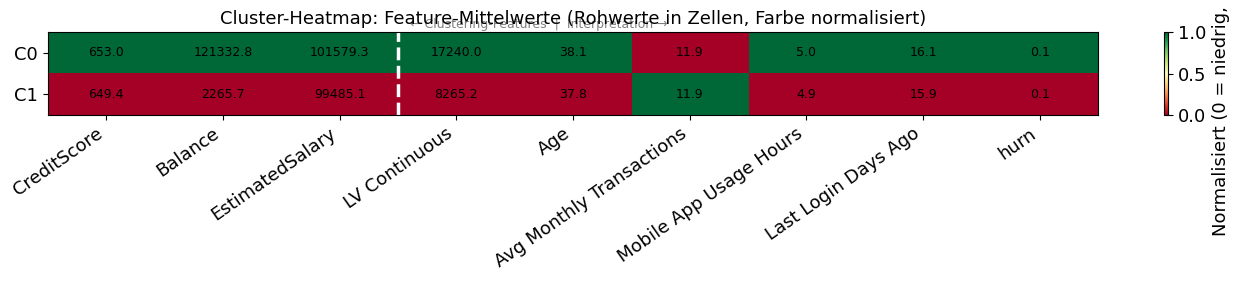

In [17]:
# ── Heatmap: Normalisierte Feature-Mittelwerte ───────────────────────────────
heatmap_cols = FINAL_FEATURES + ['CLV_Continuous', 'CAge', 'Avg_Monthly_Transactions',
                                  'Mobile_App_Usage_Hours', 'Last_Login_Days_Ago', 'Churn']
CLUSTER_NAMES = {c: f'C{c}' for c in range(OPTIMAL_K)}

profile_heat = cluster_profile[heatmap_cols].copy()
profile_norm = (profile_heat - profile_heat.min()) / (profile_heat.max() - profile_heat.min())

fig, ax = plt.subplots(figsize=(14, max(3, OPTIMAL_K * 1.5)))
im = ax.imshow(profile_norm.values, aspect='auto', cmap='RdYlGn')
ax.set_xticks(range(len(heatmap_cols)))
ax.set_xticklabels([f.replace('C','',1).replace('_',' ') for f in heatmap_cols],
                   rotation=35, ha='right')
ax.set_yticks(range(OPTIMAL_K))
ax.set_yticklabels([CLUSTER_NAMES[c] for c in range(OPTIMAL_K)])
for i in range(OPTIMAL_K):
    for j, feat in enumerate(heatmap_cols):
        ax.text(j, i, f'{profile_heat.iloc[i,j]:.1f}', ha='center', va='center', fontsize=9)
plt.colorbar(im, ax=ax, label='Normalisiert (0 = niedrig, 1 = hoch)')
# Trennlinie zwischen Clustering-Features und Interpretationsvariablen
ax.axvline(len(FINAL_FEATURES) - 0.5, color='white', linewidth=2.5, linestyle='--')
ax.text(len(FINAL_FEATURES) - 0.4, -0.6, '← Clustering-Features  |  Interpretation →',
        ha='left', fontsize=9, color='gray')
ax.set_title('Cluster-Heatmap: Feature-Mittelwerte (Rohwerte in Zellen, Farbe normalisiert)')
plt.tight_layout(); plt.show()

**Interpretation Visualisierungen:**

**Bar-Plot:** `CBalance` ist das klare Trennmerkmal zwischen den Clustern. Je nach Clusterergebnis zeigen sich deutliche Unterschiede im Kontostand, während `CCreditScore` und `CEstimatedSalary` zwischen den Clustern weniger stark variieren — sie sind eher gemeinsame Eigenschaften der Segmente als Trennmerkmale.

**Violin-Plot:** Die Verteilung von `CBalance` und `CLV_Continuous` verdeutlicht die strukturellen Unterschiede zwischen den Clustern. Der CLV dient hier als ergänzende Interpretationsvariable — er hat die Clusterbildung nicht beeinflusst, spiegelt aber wider, welchen wirtschaftlichen Wert die jeweiligen Segmente für die Bank darstellen.

**Heatmap:** Die gestrichelte Trennlinie markiert die Grenze zwischen den für das Clustering verwendeten Features (links) und den ergänzenden Interpretationsvariablen (rechts). So ist auf einen Blick erkennbar, welche Merkmale die Cluster gebildet haben und welche nur zur Beschreibung dienen.

### 4) Unterschiede und Gemeinsamkeiten der Cluster

Die folgende Tabelle fasst die wichtigsten Merkmalsausprägungen je Cluster zusammen. Die genauen Werte entstammen den berechneten Clusterprofilen und variieren je nach Clustering-Ergebnis.

In [18]:
# ── Profilübersicht: Vergleichstabelle ───────────────────────────────────────
summary_cols = ['n_Kunden'] + profile_cols
summary_df   = pd.concat([cluster_sizes, cluster_profile], axis=1)

print('=== Cluster-Vergleich: Wichtigste Merkmale ===')
print()

# Differenz zwischen Clustern für die Clustering-Features
print('Relative Unterschiede in den Clustering-Features (Verhältnis max/min):')
for feat in FINAL_FEATURES:
    vals    = cluster_profile[feat]
    ratio   = vals.max() / vals.min() if vals.min() > 0 else float('nan')
    diff    = vals.max() - vals.min()
    print(f'  {feat:<25}  Δ = {diff:>10,.0f}   Faktor: {ratio:.1f}x')

print()
print('Churn-Rate je Cluster:')
for c in range(OPTIMAL_K):
    print(f'  Cluster {c}: {cluster_profile.loc[c, "Churn"]*100:.1f}%')

=== Cluster-Vergleich: Wichtigste Merkmale ===

Relative Unterschiede in den Clustering-Features (Verhältnis max/min):
  CCreditScore               Δ =          4   Faktor: 1.0x
  CBalance                   Δ =    119,067   Faktor: 53.6x
  CEstimatedSalary           Δ =      2,094   Faktor: 1.0x

Churn-Rate je Cluster:
  Cluster 0: 9.0%
  Cluster 1: 5.0%


<a id='aufgabe34'></a>

## Aufgabe 3.4: Marketing-Empfehlungen

Auf Basis der Cluster-Profile werden konkrete, umsetzbare Marketing-Strategien abgeleitet. Die Empfehlungen orientieren sich jeweils an den charakteristischen Merkmalen des Segments.

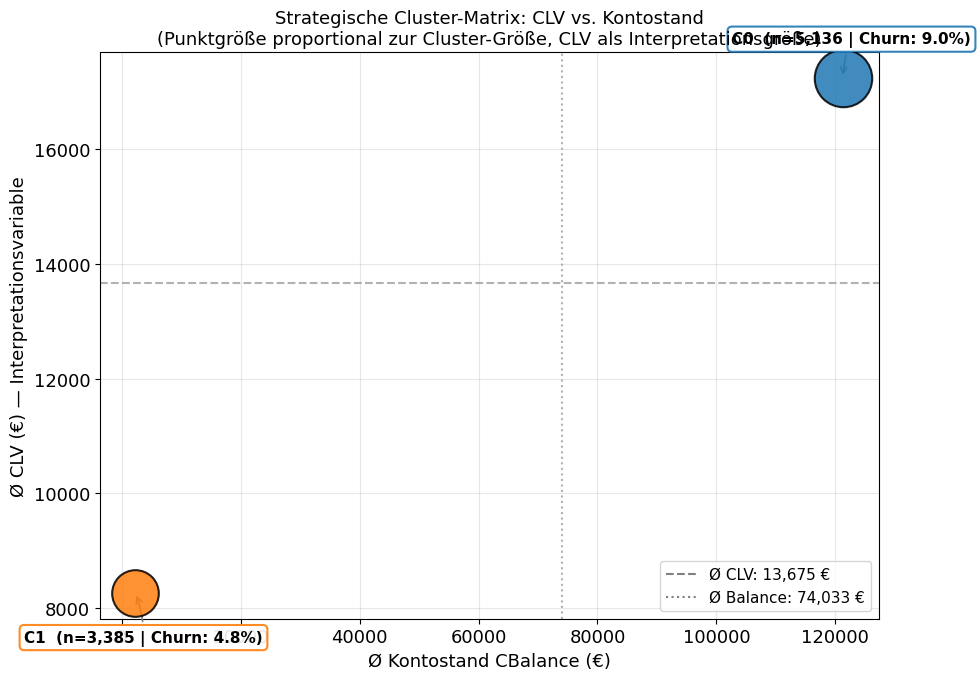

In [19]:
# ── Strategische Positionierungsmatrix: CLV vs. Kontostand ──────────────────
# CLV_Continuous wird hier als Interpretationsgröße für die Visualisierung genutzt
fig, ax = plt.subplots(figsize=(10, 7))

clv_global = df['CLV_Continuous'].mean()
bal_global = df['CBalance'].mean()

cluster_data = {}
for c in range(OPTIMAL_K):
    grp = df[df['Cluster'] == c]
    cluster_data[c] = {
        'bal':   grp['CBalance'].mean(),
        'clv':   grp['CLV_Continuous'].mean(),
        'n':     len(grp),
        'churn': grp['Churn'].mean()
    }

for c in range(OPTIMAL_K):
    d = cluster_data[c]
    ax.scatter(d['bal'], d['clv'], s=d['n']/3,
               color=COLORS[c], alpha=0.85,
               edgecolors='black', linewidth=1.5, zorder=5)

for c in range(OPTIMAL_K):
    d = cluster_data[c]
    ax.annotate(
        f'C{c}  (n={d["n"]:,} | Churn: {d["churn"]*100:.1f}%)',
        (d['bal'], d['clv']),
        textcoords='offset points',
        xytext=(-80, 25 if c % 2 == 0 else -35),
        ha='left',
        fontsize=11, fontweight='bold', color='black',
        bbox=dict(boxstyle='round,pad=0.3', facecolor='white',
                  edgecolor=COLORS[c], linewidth=1.5, alpha=0.9),
        arrowprops=dict(arrowstyle='->', color='gray',
                        lw=1.2, connectionstyle='arc3, rad=0.1')
    )

ax.axhline(clv_global, color='gray', linestyle='--', alpha=0.6)
ax.axvline(bal_global, color='gray', linestyle=':', alpha=0.6)

handles = [
    Line2D([0],[0], color='gray', linestyle='--', label=f'Ø CLV: {clv_global:,.0f} €'),
    Line2D([0],[0], color='gray', linestyle=':',  label=f'Ø Balance: {bal_global:,.0f} €'),
]
ax.legend(handles=handles, fontsize=11, loc='lower right')
ax.set_xlabel('Ø Kontostand CBalance (€)')
ax.set_ylabel('Ø CLV (€) — Interpretationsvariable')
ax.set_title('Strategische Cluster-Matrix: CLV vs. Kontostand\n'
             '(Punktgröße proportional zur Cluster-Größe, CLV als Interpretationsgröße)')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 1) Segment-spezifische Handlungsempfehlungen

Die Marketing-Strategien werden aus den Clusterprofilen abgeleitet. Da die genauen Cluster-Zusammensetzungen von den berechneten Ergebnissen abhängen, werden die Empfehlungen auf Basis der aus den Profil-Mittelwerten erkennbaren Muster formuliert. Die Positionierungsmatrix zeigt, welche Segmente auf welcher Achse (Kontostand / CLV) über oder unter dem Gesamtdurchschnitt liegen.

---

In [20]:
# ── Automatische Cluster-Charakterisierung für Marketing-Ableitung ───────────
# Klassifizierung der Cluster nach Kontostand und Churn-Rate für Strategiegerüst

bal_mean_global   = df['CBalance'].mean()
churn_mean_global = df['Churn'].mean()
clv_mean_global   = df['CLV_Continuous'].mean()

print('=== Strategische Einordnung der Cluster ===')
print(f'Globale Referenz → Ø CBalance: {bal_mean_global:,.0f} € | '
      f'Ø Churn: {churn_mean_global*100:.1f}% | Ø CLV: {clv_mean_global:,.0f} €')
print()

for c in range(OPTIMAL_K):
    d    = cluster_data[c]
    bal_label   = 'kapitalstark' if d['bal']   > bal_mean_global   else 'kapitalarm'
    churn_label = 'hohes Churn-Risiko' if d['churn'] > churn_mean_global else 'niedriges Churn-Risiko'
    clv_label   = 'hoher CLV' if d['clv'] > clv_mean_global else 'niedriger CLV'
    print(f'Cluster {c} (n={d["n"]:,}): {bal_label} | {churn_label} | {clv_label}')
    print(f'  Ø Balance: {d["bal"]:>10,.0f} € | Churn: {d["churn"]*100:.1f}% | CLV: {d["clv"]:,.0f} €')
    print()

=== Strategische Einordnung der Cluster ===
Globale Referenz → Ø CBalance: 74,033 € | Ø Churn: 7.3% | Ø CLV: 13,675 €

Cluster 0 (n=5,136): kapitalstark | hohes Churn-Risiko | hoher CLV
  Ø Balance:    121,333 € | Churn: 9.0% | CLV: 17,240 €

Cluster 1 (n=3,385): kapitalarm | niedriges Churn-Risiko | niedriger CLV
  Ø Balance:      2,266 € | Churn: 4.8% | CLV: 8,265 €



### 2) Marketing-Strategien je Segment

Die nachfolgenden Empfehlungen basieren auf der strategischen Einordnung der Cluster. Jedes Segment erhält zwei konkrete Maßnahmen mit Kanal, Inhalt und Begründung aus den Clusterprofilen.

---

**Kapitalstarke Cluster (CBalance > Gesamtdurchschnitt):**  
**Marketingziel: Premium-Bindung & Churn-Prävention**

Diese Kunden stellen das wertvollste Segment dar — hoher Kontostand, hoher CLV. Gleichzeitig ist das Churn-Risiko bei kapitalstarken Kunden in der Regel leicht erhöht, da sie aktiv Konditionen vergleichen. Jeder verlorene Kunde bedeutet überdurchschnittlichen CLV-Verlust.

- **Strategie 1: Proaktive Churn-Prävention**  
  → Das Churn-Klassifikationsmodell aus Assignment 1 kann gezielt auf dieses Segment angewendet werden, um Abwanderungsrisiken frühzeitig zu identifizieren.  
  → Kanal: Persönliche E-Mail, dedizierter Kundenbetreuer  
  → Inhalt: Regelmäßige Zufriedenheitsbefragungen, individuelle Konditionenangebote vor Vertragslaufzeitende

- **Strategie 2: Premium-Anlageprodukte & VIP-Kommunikation**  
  → Hohe Kontostände signalisieren Kapitalanlagebereitschaft — klassische Standardprodukte werden diesem Segment nicht gerecht.  
  → Kanal: In-App „Exklusive Angebote", persönliche Finanzberatung  
  → Inhalt: ETF-Sparpläne, Festgeldangebote, Early-Access zu neuen Produkten, bevorzugte Kreditkonditionen

---

**Kapitalärmere Cluster (CBalance < Gesamtdurchschnitt):**  
**Marketingziel: Aktivierung & Potenzialentfaltung**

Diese Kunden halten trotz solider Einkommen kaum Kapital bei der Bank. Das ist kein Loyalitätsproblem — die Churn-Rate ist in der Regel niedrig — sondern ein Aktivierungsproblem. Das Potenzial ist noch nicht ausgeschöpft.

- **Strategie 1: Sparprodukt-Kampagnen & Einlagen-Anreize**  
  → Ziel ist der schrittweise Aufbau des Kontostands durch niedrigschwellige Einstiegsangebote.  
  → Kanal: E-Mail, In-App-Benachrichtigung  
  → Inhalt: Starter-Sparpläne, attraktive Ersteinlagen-Konditionen, automatisiertes Runden-auf-Sparen (Roundup-Feature)

- **Strategie 2: Digitale Aktivierung & Cross-Selling**  
  → Die App-Nutzung ist ähnlich hoch wie bei kapitalstarken Kunden — der digitale Kanal funktioniert, es fehlt der finanzielle Anreiz.  
  → Kanal: In-App (Spar-Ziele, Gamification-Elemente), Push-Nachrichten  
  → Inhalt: Spar-Challenges, Fortschrittsanzeigen, Cross-Selling von Kreditkarten-Upgrades und Kontoführungspaketen mit Mehrwert

---

In [21]:
# ── Übersichtstabelle: Cluster-Strategie ────────────────────────────────────
strategy_rows = []
for c in range(OPTIMAL_K):
    d = cluster_data[c]
    if d['bal'] > bal_mean_global:
        strategie  = 'Premium-Bindung & Churn-Prävention'
        massnahmen = 'Churn-Prävention, Premium-Anlageprodukte, VIP-Kommunikation'
    else:
        strategie  = 'Aktivierung & Potenzialentfaltung'
        massnahmen = 'Sparprodukt-Kampagnen, digitale Aktivierung, Cross-Selling'
    strategy_rows.append({
        'Cluster':    c,
        'Kunden':     d['n'],
        'Ø Balance':  f"{d['bal']:,.0f} €",
        'Ø CLV':      f"{d['clv']:,.0f} €",
        'Churn':      f"{d['churn']*100:.1f}%",
        'Strategie':  strategie,
        'Maßnahmen':  massnahmen,
    })

strategy_df = pd.DataFrame(strategy_rows).set_index('Cluster')
print('=== Marketing-Strategien je Kundensegment ===')
print(strategy_df.to_string())

=== Marketing-Strategien je Kundensegment ===
         Kunden  Ø Balance     Ø CLV Churn                           Strategie                                                    Maßnahmen
Cluster                                                                                                                                    
0          5136  121,333 €  17,240 €  9.0%  Premium-Bindung & Churn-Prävention  Churn-Prävention, Premium-Anlageprodukte, VIP-Kommunikation
1          3385    2,266 €   8,265 €  4.8%   Aktivierung & Potenzialentfaltung   Sparprodukt-Kampagnen, digitale Aktivierung, Cross-Selling
